# Task 1: Data Understanding and Visualization

## Step 1: Import Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import random

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


## Step 2: Set Dataset Paths

In [2]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/Machine Learning/Week5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/Machine Learning/Week5/FruitinAmazon/test"

# Verify paths exist
if os.path.exists(train_dir):
    print(f"Training directory found: {train_dir}")
else:
    print(f"Training directory not found: {train_dir}")

if os.path.exists(test_dir):
    print(f"Test directory found: {test_dir}")
else:
    print(f"Test directory not found: {test_dir}")

Training directory found: /content/drive/MyDrive/Machine Learning/Week5/FruitinAmazon/train
Test directory found: /content/drive/MyDrive/Machine Learning/Week5/FruitinAmazon/test


## Step 3: Visualize Sample Images from Each Class

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


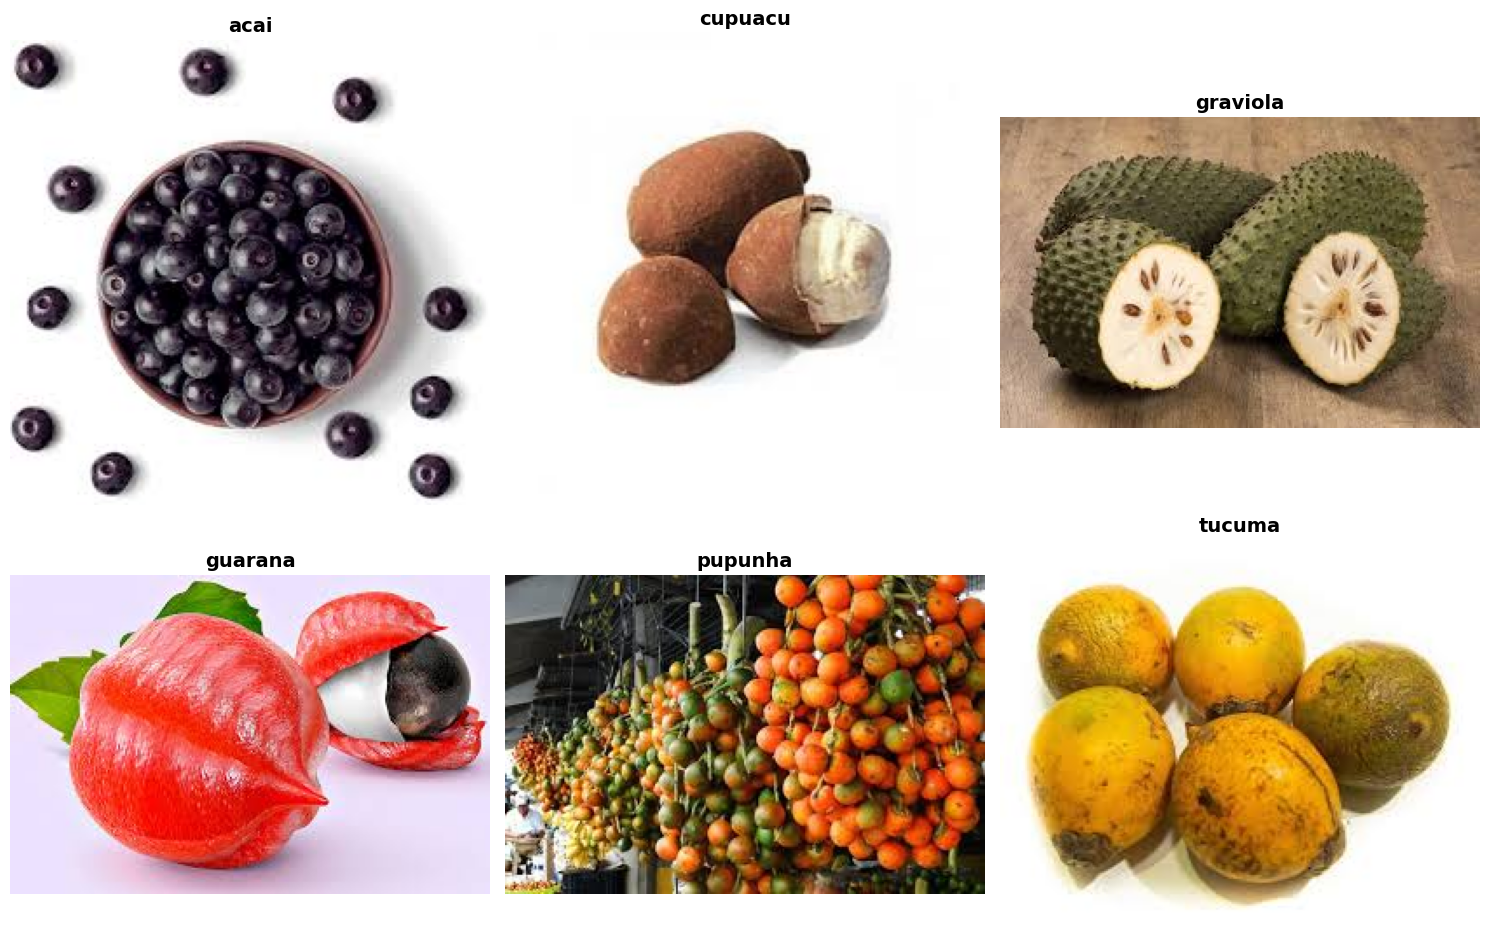

Observation:
------------------------------------------------------------
The dataset contains 6 different Amazon fruit classes:
  1. acai
  2. cupuacu
  3. graviola
  4. guarana
  5. pupunha
  6. tucuma

Each class has images of different sizes and aspect ratios.
Images will need to be resized to a consistent size for training.


In [3]:
# Get list of class directories
class_names = sorted(os.listdir(train_dir))

# Filter out non-directory items
class_names = [c for c in class_names if os.path.isdir(os.path.join(train_dir, c))]

print(f"Found {len(class_names)} classes: {class_names}")

# Create figure for visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select and display one random image from each class
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)

    # Get list of images in this class
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(image_files) > 0:
        # Select random image
        random_image = random.choice(image_files)
        image_path = os.path.join(class_path, random_image)

        # Load and display image
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=14, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No images found',
                     ha='center', va='center')
        axes[i].set_title(class_name, fontsize=14)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Observation:")
print("-"*60)
print("The dataset contains 6 different Amazon fruit classes:")
for idx, name in enumerate(class_names, 1):
    print(f"  {idx}. {name}")
print("\nEach class has images of different sizes and aspect ratios.")
print("Images will need to be resized to a consistent size for training.")

## Step 4: Check for Corrupted Images

In [4]:
def check_corrupted_images(directory):
    """
    Check for corrupted images in the dataset and remove them.

    Parameters:
    - directory: Path to the directory containing class subdirectories

    Returns:
    - List of corrupted image paths that were removed
    """
    corrupted_images = []

    # Get class directories
    class_names = sorted(os.listdir(directory))
    class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    print("Checking for corrupted images...")
    print("-"*60)

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)

        # Get all image files
        image_files = [f for f in os.listdir(class_path)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for image_file in image_files:
            image_path = os.path.join(class_path, image_file)

            try:
                # Try to open the image
                img = Image.open(image_path)
                img.verify()  # Verify that it is an image
                img.close()

                # Try to load it again (verify() closes the file)
                img = Image.open(image_path)
                img.load()  # Actually load the image data
                img.close()

            except (IOError, SyntaxError) as e:
                # Image is corrupted
                print(f"Removed corrupted image: {image_path}")
                os.remove(image_path)
                corrupted_images.append(image_path)

    print("-"*60)

    if len(corrupted_images) == 0:
        print("✓ No corrupted images found.")
    else:
        print(f"Removed {len(corrupted_images)} corrupted image(s).")

    return corrupted_images

# Check training directory
corrupted_train = check_corrupted_images(train_dir)

# Check test directory
corrupted_test = check_corrupted_images(test_dir)

Checking for corrupted images...
------------------------------------------------------------
------------------------------------------------------------
✓ No corrupted images found.
Checking for corrupted images...
------------------------------------------------------------
------------------------------------------------------------
✓ No corrupted images found.


## Step 5: Define Image Parameters

In [5]:
# Image parameters
img_height = 128
img_width = 128
batch_size = 16  # As specified in Task 4
validation_split = 0.2  # 80% train, 20% validation

print("Image Processing Parameters:")
print(f"  Image Size: {img_height}x{img_width}")
print(f"  Batch Size: {batch_size}")
print(f"  Validation Split: {validation_split} (80% train, 20% validation)")

Image Processing Parameters:
  Image Size: 128x128
  Batch Size: 16
  Validation Split: 0.2 (80% train, 20% validation)


## Step 6: Create Rescaling Layer

In [6]:
# Create preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)

print("Normalization layer created: Rescaling(1./255)")
print("  Pixel values will be normalized from [0, 255] to [0, 1]")

Normalization layer created: Rescaling(1./255)
  Pixel values will be normalized from [0, 255] to [0, 1]


## Step 7: Load Training Dataset

In [7]:
# Load training dataset
print("\n" + "="*60)
print("Loading Training Dataset...")
print("="*60)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Training dataset loaded")
print(f"Found {num_classes} classes: {class_names}")

# Apply normalization only
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

print("Training dataset normalized")

Loading Training Dataset...
------------------------------------------------------------
Found 90 files belonging to 6 classes.
Using 72 files for training.
Training dataset loaded
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Training dataset normalized


## Step 8: Load Validation Dataset

In [8]:
# Load validation dataset
print("Loading Validation Dataset...")
print("-"*60)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Validation dataset loaded and normalized")

Loading Validation Dataset...
------------------------------------------------------------
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Validation dataset loaded and normalized


## Step 9: Load Test Dataset

In [9]:
# Load test dataset
print("Loading Test Dataset...")
print("-"*60)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

# Apply normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("Test dataset loaded and normalized")

Loading Test Dataset...
------------------------------------------------------------
Found 30 files belonging to 6 classes.
Test dataset loaded and normalized


## Step 10: Get Class Names and Display Dataset Info

In [10]:
# Display dataset information
print("DATASET INFORMATION")
print("\n")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"\nImage specifications:")
print(f"  Input shape: ({img_height}, {img_width}, 3)")
print(f"  Batch size: {batch_size}")
print(f"  Data type: float32 (normalized to [0, 1])")
print("\n")

DATASET INFORMATION


Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Image specifications:
  Input shape: (128, 128, 3)
  Batch size: 16
  Data type: float32 (normalized to [0, 1])




## Step 11: Optimize Dataset Performance

In [11]:
# Optimize dataset performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets optimized with caching and prefetching")

Datasets optimized with caching and prefetching


# Task 3: Build CNN Model

## Step 12: Build the CNN Model

In [12]:
# Clear any previous models
tf.keras.backend.clear_session()

# Build simpler CNN model
model = keras.Sequential([
    # Input layer
    keras.layers.Input(shape=(img_height, img_width, 3)),

    # Convolutional Block 1
    keras.layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu',
                        name='conv_layer_1'),
    keras.layers.MaxPooling2D((2, 2), strides=2, name='max_pool_1'),

    # Convolutional Block 2
    keras.layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu',
                        name='conv_layer_2'),
    keras.layers.MaxPooling2D((2, 2), strides=2, name='max_pool_2'),

    # Flatten layer
    keras.layers.Flatten(name='flatten'),

    # Fully Connected Layers with light dropout
    keras.layers.Dense(64, activation='relu', name='dense_1'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu', name='dense_2'),
    keras.layers.Dropout(0.3),

    # Output layer
    keras.layers.Dense(num_classes, activation='softmax', name='output_layer')
])

print("CNN Model built successfully")

CNN Model built successfully!


## Step 13: Display Model Summary

In [13]:
print("MODEL ARCHITECTURE")
print("\n")
model.summary()


MODEL ARCHITECTURE




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer_1 (Conv2D)           │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Step 14: Visualize Model Architecture

In [14]:
# Create a detailed architecture breakdown
print("DETAILED LAYER-BY-LAYER BREAKDOWN")
print("\n")

print("\n CONVOLUTIONAL LAYERS:")
print("-" * 60)
print("Layer 1: Conv2D")
print("  - Filters: 32")
print("  - Kernel Size: (3, 3)")
print("  - Padding: same")
print("  - Stride: 1")
print("  - Activation: ReLU")
print("  - Output: Maintains spatial dimensions due to 'same' padding")

print("\nLayer 2: MaxPooling2D")
print("  - Pool Size: (2, 2)")
print("  - Stride: 2")
print("  - Effect: Reduces spatial dimensions by half")

print("\nLayer 3: Conv2D")
print("  - Filters: 32")
print("  - Kernel Size: (3, 3)")
print("  - Padding: same")
print("  - Stride: 1")
print("  - Activation: ReLU")

print("\nLayer 4: MaxPooling2D")
print("  - Pool Size: (2, 2)")
print("  - Stride: 2")
print("  - Effect: Reduces spatial dimensions by half again")

print("\n FULLY CONNECTED LAYERS:")
print("-" * 60)
print("Layer 5: Flatten")
print("  - Converts 3D feature maps to 1D vector")

print("\nLayer 6: Dense (Hidden Layer 1)")
print("  - Neurons: 64")
print("  - Activation: ReLU")

print("\nLayer 7: Dense (Hidden Layer 2)")
print("  - Neurons: 128")
print("  - Activation: ReLU")

print("\nLayer 8: Dense (Output Layer)")
print(f"  - Neurons: {num_classes}")
print("  - Activation: Softmax")
print("  - Produces probability distribution over classes")



DETAILED LAYER-BY-LAYER BREAKDOWN



 CONVOLUTIONAL LAYERS:
------------------------------------------------------------
Layer 1: Conv2D
  - Filters: 32
  - Kernel Size: (3, 3)
  - Padding: same
  - Stride: 1
  - Activation: ReLU
  - Output: Maintains spatial dimensions due to 'same' padding

Layer 2: MaxPooling2D
  - Pool Size: (2, 2)
  - Stride: 2
  - Effect: Reduces spatial dimensions by half

Layer 3: Conv2D
  - Filters: 32
  - Kernel Size: (3, 3)
  - Padding: same
  - Stride: 1
  - Activation: ReLU

Layer 4: MaxPooling2D
  - Pool Size: (2, 2)
  - Stride: 2
  - Effect: Reduces spatial dimensions by half again

 FULLY CONNECTED LAYERS:
------------------------------------------------------------
Layer 5: Flatten
  - Converts 3D feature maps to 1D vector

Layer 6: Dense (Hidden Layer 1)
  - Neurons: 64
  - Activation: ReLU

Layer 7: Dense (Hidden Layer 2)
  - Neurons: 128
  - Activation: ReLU

Layer 8: Dense (Output Layer)
  - Neurons: 6
  - Activation: Softmax
  - Produces probabili

# Task 4: Compile the Model

## Step 15: Compile the Model

In [15]:
from tensorflow.keras.optimizers import Adam

# Compile with normal learning rate
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("MODEL COMPILATION")
print("="*60)
print("Model compiled successfully")
print("\nConfiguration:")
print("  Optimizer: Adam (learning_rate=0.001)")
print("  Loss Function: Sparse Categorical Crossentropy")
print("  Metrics: Accuracy")
print("="*60)

MODEL COMPILATION
------------------------------------------------------------
Model compiled successfully!

Configuration:
  Optimizer: Adam
  Loss Function: Sparse Categorical Crossentropy
  Metrics: Accuracy


# Task 5: Train the Model

## Step 16: Setup Callbacks

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Training parameters
epochs = 250

# Callbacks
callbacks = [
    ModelCheckpoint(
        filepath='best_fruit_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("TRAINING CONFIGURATION")
print("-"*60)
print(f"Maximum Epochs: {epochs}")
print(f"Batch Size: {batch_size}")
print(f"\nCallbacks:")
print("  1. ModelCheckpoint - Saves best model based on val_accuracy")
print("  2. EarlyStopping - Stops if val_loss doesn't improve for 15 epochs")
print("  3. ReduceLROnPlateau - Reduces learning rate if val_loss plateaus")


TRAINING CONFIGURATION
------------------------------------------------------------
Maximum Epochs: 250
Batch Size: 16

Callbacks:
  1. ModelCheckpoint - Saves best model based on val_accuracy
  2. EarlyStopping - Stops if val_loss doesn't improve for 15 epochs
  3. ReduceLROnPlateau - Reduces learning rate if val_loss plateaus


## Step 17: Train the Model

In [17]:
print("STARTING MODEL TRAINING")
print("-"*60)
print("This may take some time...")
print()

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING COMPLETED!")


STARTING MODEL TRAINING
------------------------------------------------------------
This may take some time...

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.2302 - loss: 1.8719
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step - accuracy: 0.2083 - loss: 1.8704 - val_accuracy: 0.5000 - val_loss: 1.7053 - learning_rate: 0.0010
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.4274 - loss: 1.6861
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 481ms/step - accuracy: 0.5278 - loss: 1.6196 - val_accuracy: 0.1667 - val_loss: 1.6624 - learning_rate: 0.0010
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3948 - loss: 1.3923
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.4583 - loss: 1.2858 - val_accuracy: 0.5000 - val_loss: 1.3046 - learning_rate: 0.0010
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.7431 - loss: 0.9451
Epoch 4: val_accuracy improved from 0.50000 to 0.66667, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.7361 - loss: 0.8123 - val_accuracy: 0.6667 - val_loss: 0.9133 - learning_rate: 0.0010
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7997 - loss: 0.6268
Epoch 5: val_accuracy improved from 0.66667 to 0.88889, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.8472 - loss: 0.5406 - val_accuracy: 0.8889 - val_loss: 0.8198 - learning_rate: 0.0010
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8795 - loss: 0.3680
Epoch 6: val_accuracy improved from 0.88889 to 0.94444, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.9028 - loss: 0.2965 - val_accuracy: 0.9444 - val_loss: 0.2927 - learning_rate: 0.0010
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9097 - loss: 0.3097
Epoch 7: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.9444 - loss: 0.2319 - val_accuracy: 0.8333 - val_loss: 0.6451 - learning_rate: 0.0010
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9549 - loss: 0.1248
Epoch 8: val_accuracy improved from 0.94444 to 1.00000, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.9722 - loss: 0.0876 - val_accuracy: 1.0000 - val_loss: 0.2780 - learning_rate: 0.0010
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9837 - loss: 0.0697
Epoch 9: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.9861 - loss: 0.0617 - val_accuracy: 0.8889 - val_loss: 0.2949 - learning_rate: 0.0010
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9712 - loss: 0.0696
Epoch 10: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 450ms/step - accuracy: 0.9861 - loss: 0.0436 - val_accuracy: 0.7778 - val_loss: 0.5313 - learning_rate: 0.0010
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9837 - loss: 0.0888
Epoch 11: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 0.9861 - loss: 0.0756 - val_accuracy: 0.8333 - val_loss: 0.5492 -

# Task 6: Evaluate the Model

## Step 18: Evaluate on Test Set

In [18]:
print("EVALUATING MODEL ON TEST SET")
print("-"*60)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\n" + "_"*60)
print("TEST SET RESULTS")
print("\n")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


EVALUATING MODEL ON TEST SET
------------------------------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7667 - loss: 0.5794

____________________________________________________________
TEST SET RESULTS


Test Loss: 0.5794
Test Accuracy: 0.7667 (76.67%)


# Task 7: Save and Load Model

## Step 19: Save the Model

In [19]:
import os

model_filename = 'fruit_cnn_model.keras'

try:
    model.save(model_filename)
    print(f"Model saved successfully as: {model_filename}")

    file_size = os.path.getsize(model_filename) / (1024 * 1024)
    print(f"  File size: {file_size:.2f} MB")
    print(f"  File location: {os.path.abspath(model_filename)}")

except Exception as e:
    print(f"Error saving model: {e}")

Model saved successfully as: devnagari_fcn_model.h5
  File size: 24.26 MB
  File location: /content/devnagari_fcn_model.h5


## Step 20: Load and Verify Model

In [20]:
# Load the saved model
loaded_model = tf.keras.models.load_model(model_filename)

print("MODEL LOADED")
print("_"*60)
print(f" Model loaded from: {model_filename}")

# Re-evaluate loaded model
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds, verbose=0)

print("\nVerification:")
print(f"  Original Model - Test Accuracy: {test_accuracy:.4f}")
print(f"  Loaded Model   - Test Accuracy: {loaded_test_accuracy:.4f}")

if abs(test_accuracy - loaded_test_accuracy) < 1e-5:
    print("\n Models are identical!")
else:
    print("\n Minor differences (normal due to floating point precision)")



MODEL LOADED
____________________________________________________________
 Model loaded from: devnagari_fcn_model.h5

Verification:
  Original Model - Test Accuracy: 0.7667
  Loaded Model   - Test Accuracy: 0.7667

 Models are identical!


# Task 8: Predictions and Classification Report

## Step 21: Make Predictions

In [21]:
# Make predictions on test set
print("GENERATING PREDICTIONS")
print("_"*60)

predictions = model.predict(test_ds, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels
true_classes = np.concatenate([y for x, y in test_ds], axis=0)

print(f"\n Predictions generated for {len(predicted_classes)} test images")


GENERATING PREDICTIONS
____________________________________________________________
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step

 Predictions generated for 30 test images


## Step 22: Classification Report

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("CLASSIFICATION REPORT")
print("_"*60)

# Generate classification report
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=2
)

print(report)


CLASSIFICATION REPORT
____________________________________________________________
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.71      1.00      0.83         5
    graviola       0.83      1.00      0.91         5
     guarana       0.80      0.80      0.80         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.77        30
   macro avg       0.78      0.77      0.75        30
weighted avg       0.78      0.77      0.75        30



## Step 23: Confusion Matrix

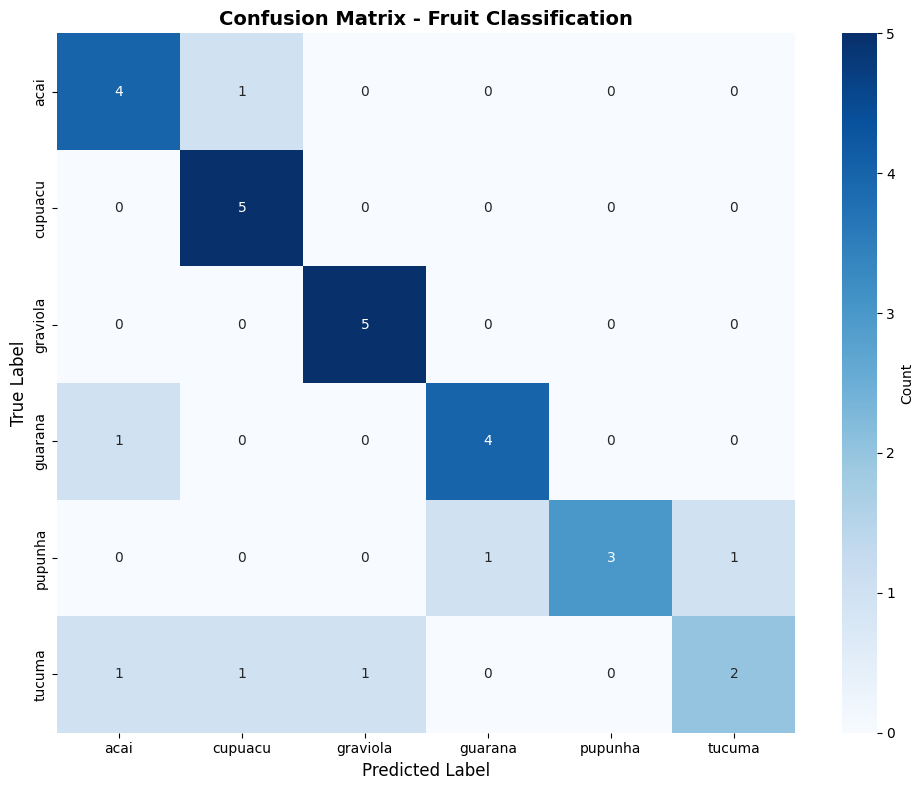

In [23]:
# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Fruit Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Visualization: Training History

## Plot Training History

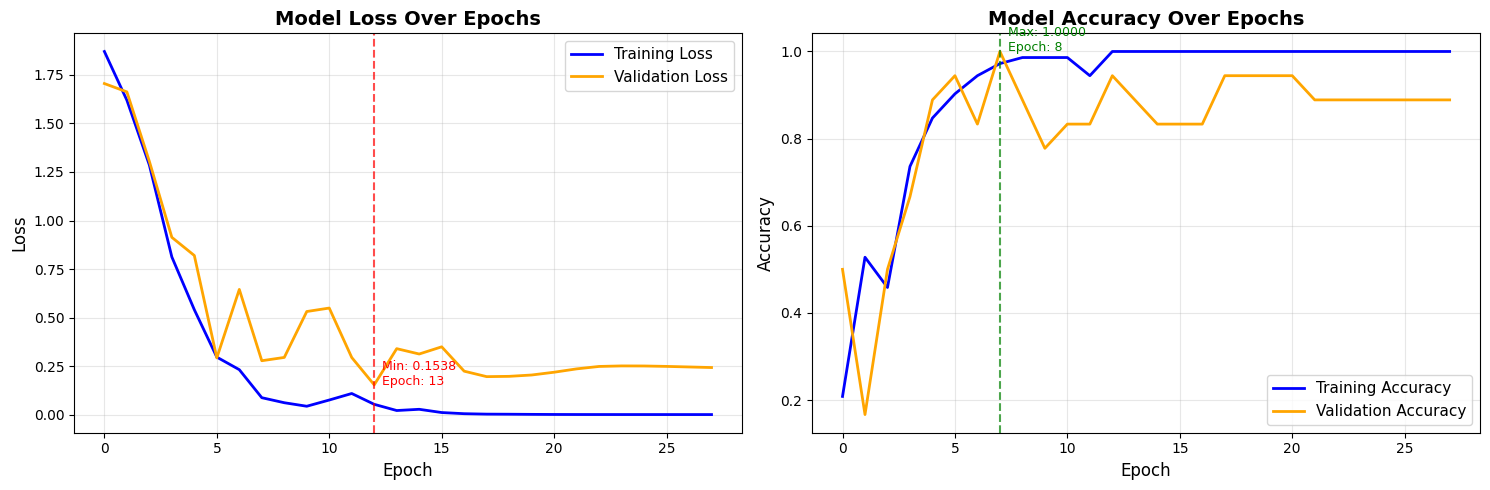

In [24]:
# Extract training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(train_loss, label='Training Loss', color='blue', linewidth=2)
ax1.plot(val_loss, label='Validation Loss', color='orange', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Highlight minimum validation loss
min_val_loss_epoch = np.argmin(val_loss)
min_val_loss = np.min(val_loss)
ax1.axvline(x=min_val_loss_epoch, color='red', linestyle='--', alpha=0.7)
ax1.text(min_val_loss_epoch, min_val_loss,
         f'  Min: {min_val_loss:.4f}\n  Epoch: {min_val_loss_epoch+1}',
         fontsize=9, color='red')

# Plot accuracy
ax2.plot(train_acc, label='Training Accuracy', color='blue', linewidth=2)
ax2.plot(val_acc, label='Validation Accuracy', color='orange', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Highlight maximum validation accuracy
max_val_acc_epoch = np.argmax(val_acc)
max_val_acc = np.max(val_acc)
ax2.axvline(x=max_val_acc_epoch, color='green', linestyle='--', alpha=0.7)
ax2.text(max_val_acc_epoch, max_val_acc,
         f'  Max: {max_val_acc:.4f}\n  Epoch: {max_val_acc_epoch+1}',
         fontsize=9, color='green')

plt.tight_layout()
plt.show()

## Visualize Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


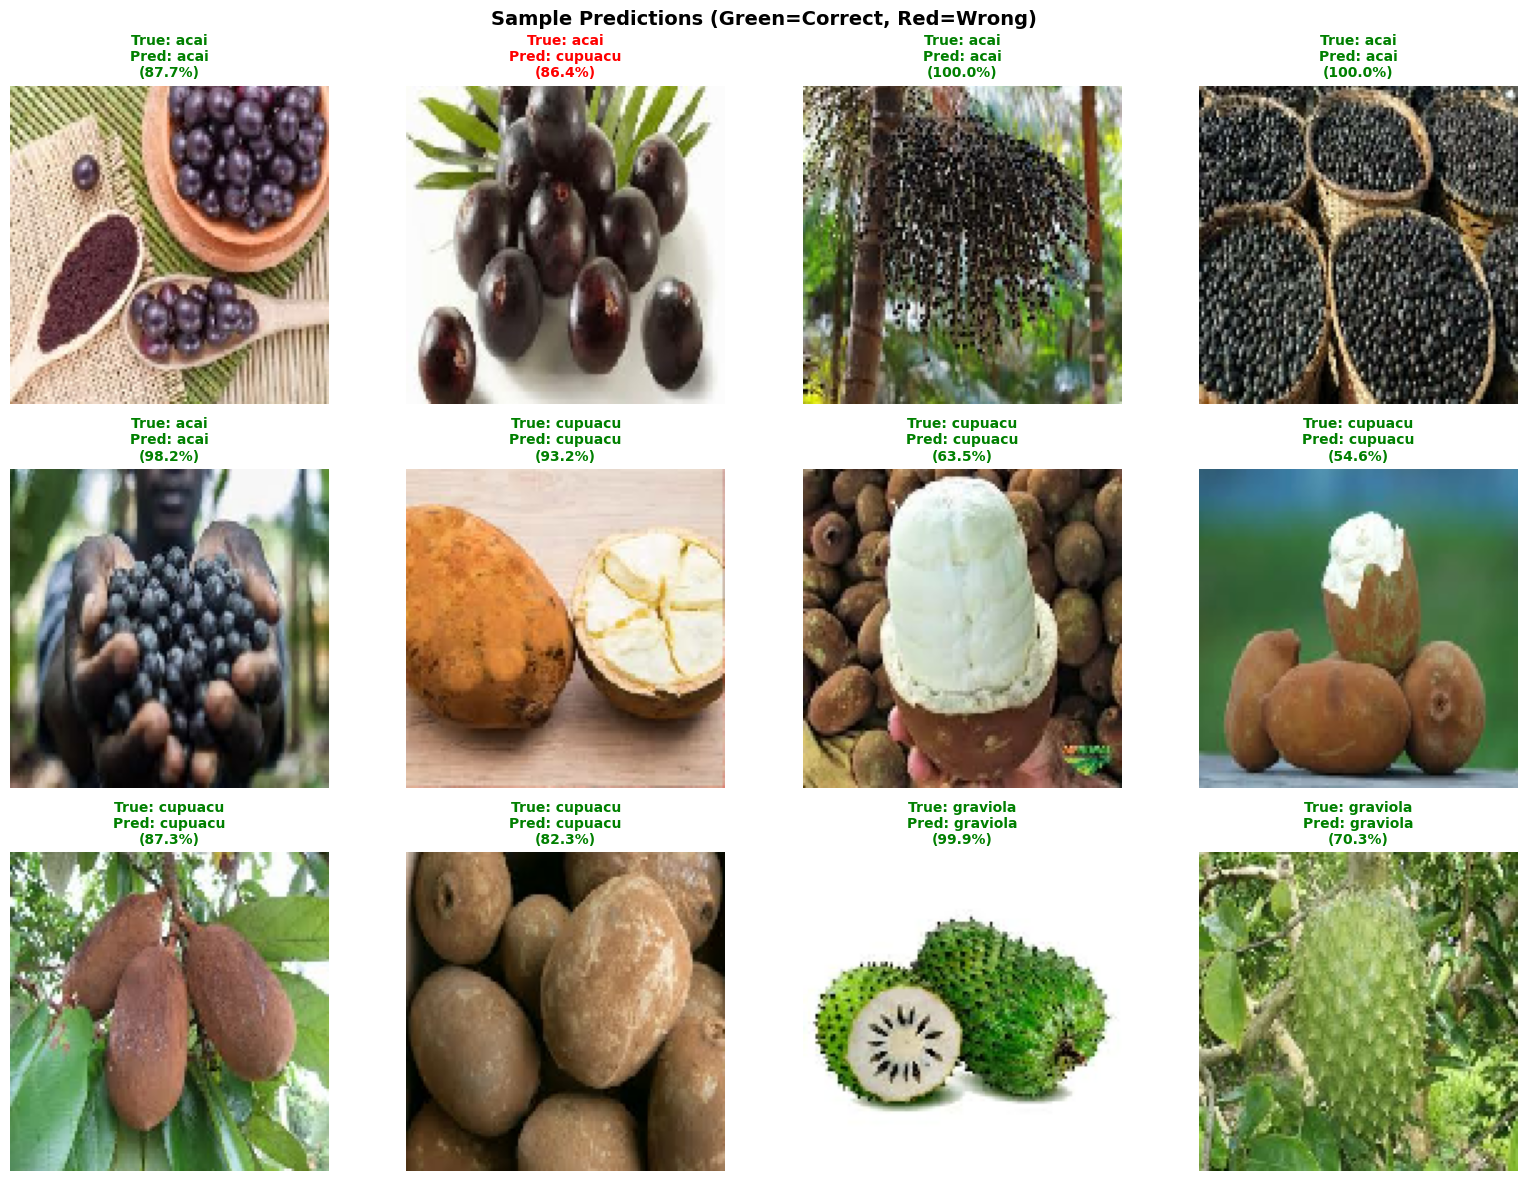

In [25]:
# Visualize some predictions
num_samples = 12

# Get a batch from test dataset
for images, labels in test_ds.take(1):
    break

# Make predictions on this batch
batch_predictions = model.predict(images[:num_samples])
batch_predicted_classes = np.argmax(batch_predictions, axis=1)

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(num_samples):
    axes[i].imshow(images[i].numpy())

    true_label = class_names[labels[i].numpy()]
    pred_label = class_names[batch_predicted_classes[i]]
    confidence = batch_predictions[i][batch_predicted_classes[i]] * 100

    # Color: green if correct, red if wrong
    color = 'green' if batch_predicted_classes[i] == labels[i].numpy() else 'red'

    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)",
                      fontsize=10, color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Per-Class Accuracy

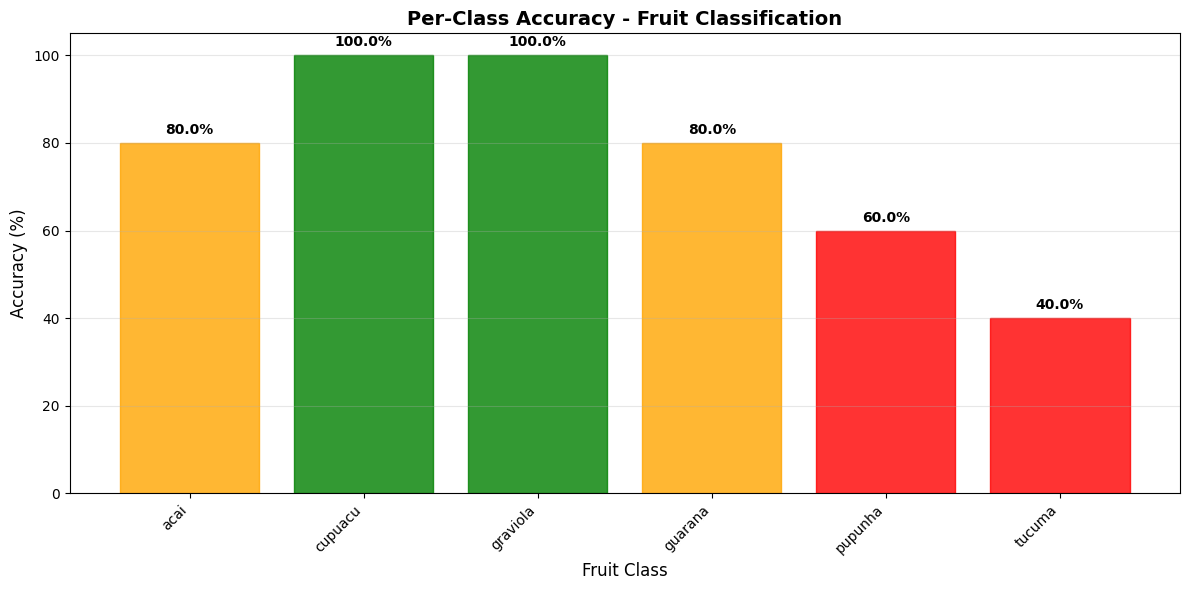


Per-Class Accuracy:
  acai: 80.00%
  cupuacu: 100.00%
  graviola: 100.00%
  guarana: 80.00%
  pupunha: 60.00%
  tucuma: 40.00%


In [26]:
# Calculate per-class accuracy
from sklearn.metrics import accuracy_score

class_accuracies = []

for i, class_name in enumerate(class_names):
    # Get indices for this class
    class_indices = (true_classes == i)

    if np.sum(class_indices) > 0:
        class_acc = accuracy_score(
            true_classes[class_indices],
            predicted_classes[class_indices]
        )
        class_accuracies.append(class_acc * 100)
    else:
        class_accuracies.append(0)

# Plot per-class accuracy
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, class_accuracies, color='steelblue', edgecolor='black', alpha=0.8)

# Color bars based on accuracy
for i, bar in enumerate(bars):
    if class_accuracies[i] >= 90:
        bar.set_color('green')
    elif class_accuracies[i] >= 75:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.xlabel('Fruit Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy - Fruit Classification', fontsize=14, fontweight='bold')
plt.ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(class_accuracies):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for i, (name, acc) in enumerate(zip(class_names, class_accuracies)):
    print(f"  {name}: {acc:.2f}%")

## Final Summary

In [27]:
print("FINAL MODEL SUMMARY")
print("_"*60)

print(f"\nModel Architecture:")
print(f"  Convolutional Layers: 2 (32 filters each, 3x3 kernel)")
print(f"  Pooling Layers: 2 (2x2 max pooling)")
print(f"  Dense Layers: 2 (64 and 128 neurons)")
print(f"  Output Layer: {num_classes} neurons (softmax)")

print(f"\nTraining Configuration:")
print(f"  Optimizer: Adam")
print(f"  Loss Function: Sparse Categorical Crossentropy")
print(f"  Batch Size: {batch_size}")
print(f"  Total Epochs Trained: {len(train_loss)}")
print(f"  Image Size: {img_height}x{img_width}")

print(f"\nDataset:")
print(f"  Classes: {class_names}")
print(f"  Number of Classes: {num_classes}")

print(f"\nPerformance:")
print(f"  Final Training Loss: {train_loss[-1]:.4f}")
print(f"  Final Training Accuracy: {train_acc[-1]:.4f} ({train_acc[-1]*100:.2f}%)")
print(f"  Final Validation Loss: {val_loss[-1]:.4f}")
print(f"  Final Validation Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print(f"\nModel Saved: {model_filename}")


FINAL MODEL SUMMARY
____________________________________________________________

Model Architecture:
  Convolutional Layers: 2 (32 filters each, 3x3 kernel)
  Pooling Layers: 2 (2x2 max pooling)
  Dense Layers: 2 (64 and 128 neurons)
  Output Layer: 6 neurons (softmax)

Training Configuration:
  Optimizer: Adam
  Loss Function: Sparse Categorical Crossentropy
  Batch Size: 16
  Total Epochs Trained: 28
  Image Size: 128x128

Dataset:
  Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
  Number of Classes: 6

Performance:
  Final Training Loss: 0.0007
  Final Training Accuracy: 1.0000 (100.00%)
  Final Validation Loss: 0.2429
  Final Validation Accuracy: 0.8889 (88.89%)
  Test Loss: 0.5794
  Test Accuracy: 0.7667 (76.67%)

Model Saved: devnagari_fcn_model.h5
